# Pertemuan 2: Data Preprocessing dan EDA
Nama  : ILMA AQSARI  
NIM   : 105841108023  

Penjelasan:

Pada pertemuan ini dilakukan proses Data Preprocessing dan Exploratory Data Analysis (EDA)
menggunakan dataset Titanic.

Tahapan yang dilakukan:
1. Memeriksa ukuran dan tipe data
2. Menangani missing value
3. Menghapus data duplikat
4. Menangani outlier dengan metode IQR
5. Melakukan normalisasi data (StandardScaler)
6. Membuat visualisasi data

Tujuan preprocessing adalah agar data menjadi lebih bersih dan siap digunakan
untuk proses Machine Learning.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

============================================================
## Load Dataset Titanic
============================================================

In [ ]:
df = sns.load_dataset("titanic")

print("=== Ukuran Data Awal ===")
print("Shape:", df.shape)

print("\nTipe Kolom:")
print(df.dtypes)

=== Ukuran Data Awal ===
Shape: (891, 15)

Tipe Kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [ ]:
print("\n=== Info Dataset ===")
print(df.info())


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
print("\n=== Statistik Awal ===")
print(df.describe())


=== Statistik Awal ===
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


## Membaca Dataset

Dataset dibaca menggunakan Pandas agar dapat diolah lebih mudah.  
Setelah dataset dibaca, saya dapat melihat jumlah data dan kolom yang tersedia.

============================================================
## 1 Missing Value
============================================================

In [ ]:
print("\n=== Missing Value Sebelum ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df["deck"] = df["deck"].cat.add_categories("Unknown").fillna("Unknown")

print("\n=== Missing Value Sesudah ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== Missing Value Sebelum ===
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

=== Missing Value Sesudah ===
Series([], dtype: int64)


============================================================
## 2 Duplikat
============================================================

In [ ]:
print("\n=== Duplikat ===")
print("Jumlah duplikat:", df.duplicated().sum())

df = df.drop_duplicates()


=== Duplikat ===
Jumlah duplikat: 110


============================================================
## 3 Outlier IQR
============================================================

In [ ]:
print("\n=== Outlier IQR ===")

for col in ["fare","age"]:
    Q1,Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3-Q1
    low = Q1-1.5*IQR
    high = Q3+1.5*IQR
    outlier_before = ((df[col]<low) | (df[col]>high)).sum()
    df[col] = df[col].clip(low,high)
    print(col,"outlier:",outlier_before)


=== Outlier IQR ===
fare outlier: 102
age outlier: 39


============================================================
## 4 Scaling
============================================================

In [ ]:
scaler = StandardScaler()
df[["age","fare"]] = scaler.fit_transform(df[["age","fare"]])

print("\n=== Statistik Setelah Scaling ===")
print(df[["age","fare"]].describe())


=== Statistik Setelah Scaling ===
                age          fare
count  7.810000e+02  7.810000e+02
mean   1.182722e-16 -6.141054e-17
std    1.000641e+00  1.000641e+00
min   -2.170008e+00 -1.166698e+00
25%   -5.622425e-01 -8.118984e-01
50%   -1.028809e-01 -4.659132e-01
75%    5.096012e-01  3.327529e-01
max    2.117367e+00  2.049730e+00


============================================================
## 5 EDA (5 Visualisasi)============================================================

/tmp/ipython-input-1177136744.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1,1])


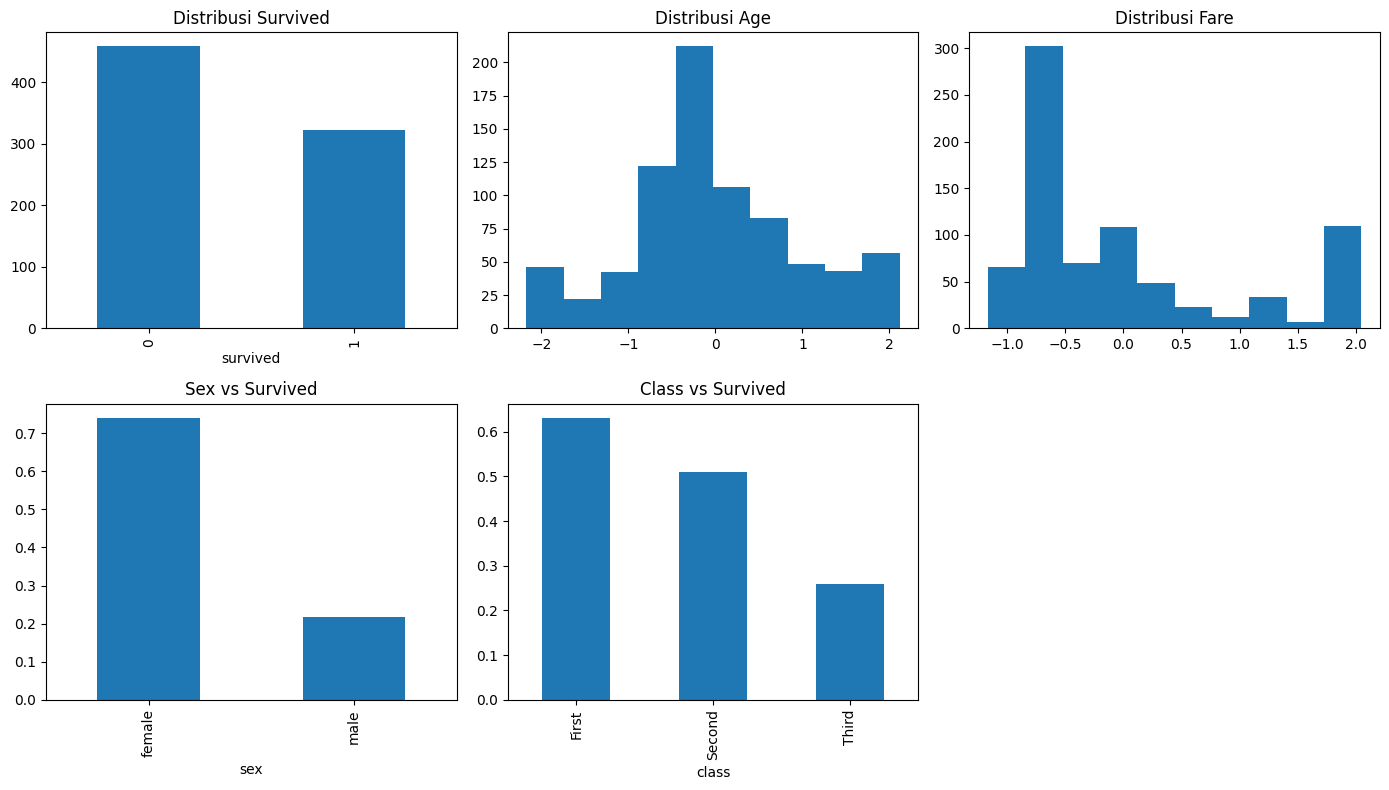


Visualisasi disimpan ke pertemuan02_eda.png


<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2,3,figsize=(14,8))

# 1 Survived
df["survived"].value_counts().plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Distribusi Survived")

# 2 Age
axes[0,1].hist(df["age"])
axes[0,1].set_title("Distribusi Age")

# 3 Fare
axes[0,2].hist(df["fare"])
axes[0,2].set_title("Distribusi Fare")

# 4 Sex vs Survived
df.groupby("sex")["survived"].mean().plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("Sex vs Survived")

# 5 Class vs Survived
df.groupby("class")["survived"].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Class vs Survived")

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

plt.savefig("pertemuan02_eda.png")

print("\nVisualisasi disimpan ke pertemuan02_eda.png")

============================================================
## Correlation Heatmap
============================================================

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("pertemuan02_heatmap.png")
plt.close()

print("Heatmap disimpan ke pertemuan02_heatmap.png")

Heatmap disimpan ke pertemuan02_heatmap.png


In [ ]:
print("\n=== 5 Insight ===")

print("1. Tingkat keselamatan sekitar",
      round(df["survived"].mean()*100,2),"%")

print("2. Perempuan memiliki peluang selamat lebih tinggi")

print("3. Penumpang kelas pertama lebih banyak selamat")

print("4. Setelah scaling nilai age dan fare memiliki mean mendekati 0")

print("5. Preprocessing membuat data lebih bersih dan siap digunakan")

print("\nPertemuan 2 selesai")


=== 5 Insight ===
1. Tingkat keselamatan sekitar 41.36 %
2. Perempuan memiliki peluang selamat lebih tinggi
3. Penumpang kelas pertama lebih banyak selamat
4. Setelah scaling nilai age dan fare memiliki mean mendekati 0
5. Preprocessing membuat data lebih bersih dan siap digunakan

Pertemuan 2 selesai


In [ ]:
print("\n✅ Pertemuan 02 selesai.")


✅ Pertemuan 02 selesai.
